# Parallelizing Neural Network Training with PyTorch (Part 1/2)


In [ ]:
from IPython.display import Image as IPythonImage
%matplotlib inline

## PyTorch and training performance

### Performance challenges

### What is PyTorch?

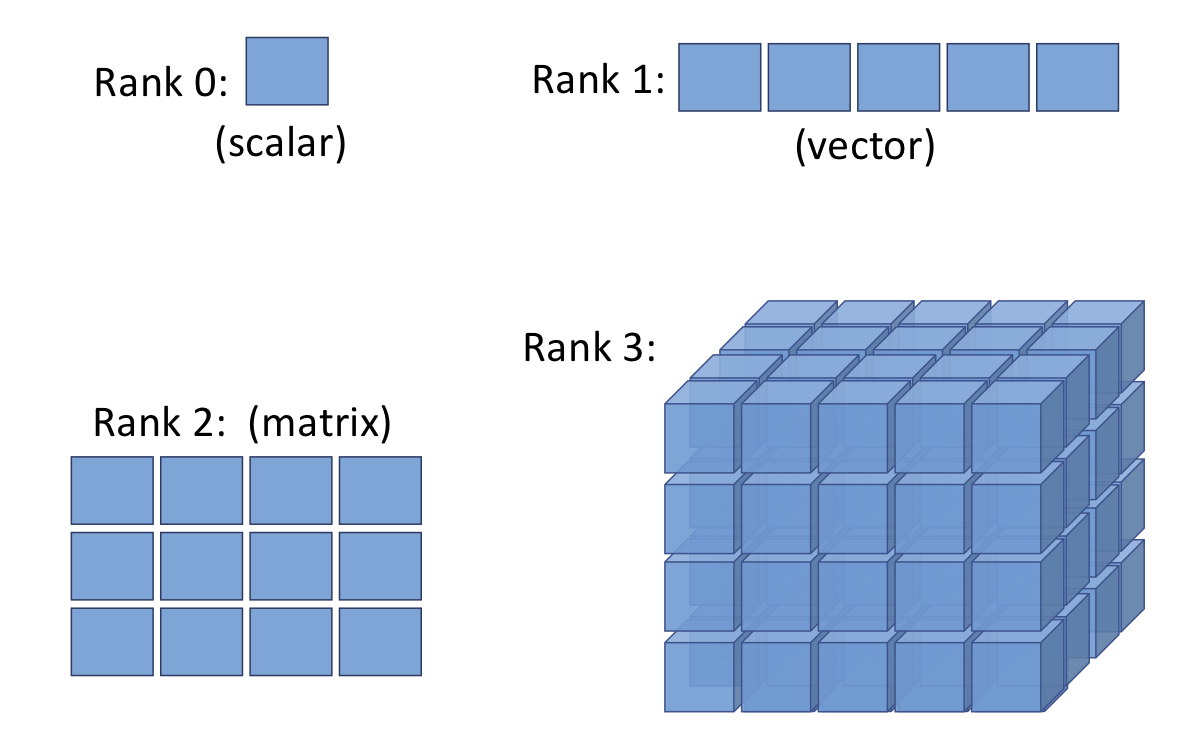

In [ ]:
IPythonImage(filename='figures/12_02.png', width=500)

## First steps with PyTorch

### Installing PyTorch

In [ ]:
#! pip install torch

In [ ]:
import torch
import numpy as np

print('PyTorch version:', torch.__version__)

np.set_printoptions(precision=3)

PyTorch version: 2.9.0+cpu


In [ ]:
! python -c 'import torch; print(torch.__version__)'

1.10.0


### Creating tensors in PyTorch

In [ ]:
a = [1, 2, 3]
b = np.array([4, 5, 6], dtype=np.int32)

t_a = torch.tensor(a)
t_b = torch.from_numpy(b)

print(t_a)
print(t_b)

tensor([1, 2, 3])
tensor([4, 5, 6], dtype=torch.int32)


In [ ]:
torch.is_tensor(a), torch.is_tensor(t_a)

(False, True)

In [ ]:
t_ones = torch.ones(2, 3)

t_ones.shape

torch.Size([2, 3])

In [ ]:
print(t_ones)

tensor([[1., 1., 1.],
        [1., 1., 1.]])


In [ ]:
rand_tensor = torch.rand(2,3)

print(rand_tensor)

tensor([[0.4103, 0.9934, 0.9537],
        [0.1607, 0.2486, 0.2230]])


In [ ]:
t_random = torch.randn(2,3)
print(t_random)

tensor([[-0.7717,  1.9583, -1.1860],
        [ 0.8874,  1.8391, -0.9394]])


### Manipulating the shape of a tensor

In [ ]:
t = torch.rand(3, 5)

t_tr = torch.transpose(t, 0, 1)
print(t.shape, ' --> ', t_tr.shape)

torch.Size([3, 5])  -->  torch.Size([5, 3])


In [ ]:
t_tr.T

tensor([[0.6659, 0.3386, 0.3893, 0.4810, 0.6721],
        [0.5088, 0.3303, 0.8426, 0.1951, 0.4045],
        [0.9111, 0.0282, 0.3049, 0.4316, 0.7279]])

In [ ]:
t = torch.zeros(30)

t_reshape = t.reshape(5, 6)
t_reshape_1 = t.reshape(-1, 6)

print(t_reshape.shape)


torch.Size([5, 6])


In [ ]:
t = torch.zeros(1, 2, 1, 4, 1)

t_sqz = torch.squeeze(t, 2)

print(t.shape, ' --> ', t_sqz.shape)

torch.Size([1, 2, 1, 4, 1])  -->  torch.Size([1, 2, 4, 1])


### Applying mathematical operations to tensors

In [ ]:
torch.manual_seed(1)
a1 = torch.rand(5, 2)
t1 = 2 * a1 - 1
print(a1)
print(t1)
t2 = torch.normal(mean=0, std=1, size=(5, 2))

print(t2)


tensor([[0.7576, 0.2793],
        [0.4031, 0.7347],
        [0.0293, 0.7999],
        [0.3971, 0.7544],
        [0.5695, 0.4388]])
tensor([[ 0.5153, -0.4414],
        [-0.1939,  0.4694],
        [-0.9414,  0.5997],
        [-0.2057,  0.5087],
        [ 0.1390, -0.1224]])
tensor([[ 0.8590,  0.7056],
        [-0.3406, -1.2720],
        [-1.1948,  0.0250],
        [-0.7627,  1.3969],
        [-0.3245,  0.2879]])


In [ ]:
t1.shape, t2.shape

(torch.Size([5, 2]), torch.Size([5, 2]))

In [ ]:
t3 = torch.multiply(t1, t2)
print(t3)

tensor([[ 0.4426, -0.3114],
        [ 0.0660, -0.5970],
        [ 1.1249,  0.0150],
        [ 0.1569,  0.7107],
        [-0.0451, -0.0352]])


In [ ]:
t4 = torch.matmul(t1.T, t2)
print(t4)

tensor([[ 1.7453,  0.3392],
        [-1.6038, -0.2180]])


In [ ]:
t4 = torch.mean(t1, axis=0)
print(t4)

tensor([-0.1373,  0.2028])


In [ ]:
t5 = torch.matmul(t1, torch.transpose(t2, 0, 1))

print(t5)

tensor([[ 0.1312,  0.3860, -0.6267, -1.0096, -0.2943],
        [ 0.1647, -0.5310,  0.2434,  0.8035,  0.1980],
        [-0.3855, -0.4422,  1.1399,  1.5558,  0.4781],
        [ 0.1822, -0.5771,  0.2585,  0.8676,  0.2132],
        [ 0.0330,  0.1084, -0.1692, -0.2771, -0.0804]])


In [ ]:
t6 = torch.matmul(torch.transpose(t1, 0, 1), t2)

print(t6)

tensor([[ 1.7453,  0.3392],
        [-1.6038, -0.2180]])


### Split, stack, and concatenate tensors

In [ ]:
torch.manual_seed(1)

t = torch.rand(6)

print(t)

t_splits = torch.chunk(t, 3)

[item.numpy() for item in t_splits]

tensor([0.7576, 0.2793, 0.4031, 0.7347, 0.0293, 0.7999])


[array([0.758, 0.279], dtype=float32),
 array([0.403, 0.735], dtype=float32),
 array([0.029, 0.8  ], dtype=float32)]

In [ ]:
torch.manual_seed(1)
t = torch.rand(5)

print(t)

t_splits = torch.split(t, split_size_or_sections=[3, 2])

[item.numpy() for item in t_splits]

tensor([0.7576, 0.2793, 0.4031, 0.7347, 0.0293])


[array([0.758, 0.279, 0.403], dtype=float32),
 array([0.735, 0.029], dtype=float32)]

In [ ]:
A = torch.ones(3)
B = torch.zeros(2)

C = torch.cat([A, B], axis=0)
print(C)

tensor([1., 1., 1., 0., 0.])


In [ ]:
A = torch.ones(3)
B = torch.zeros(3)

S = torch.stack([A, B], axis=1)
print(S)

tensor([[1., 0.],
        [1., 0.],
        [1., 0.]])


In [ ]:
A = torch.ones((3,2))
B = torch.zeros((3,2))

S = torch.stack([A, B], axis=0)
print(S)

tensor([[[1., 1.],
         [1., 1.],
         [1., 1.]],

        [[0., 0.],
         [0., 0.],
         [0., 0.]]])


## Building input pipelines in PyTorch

### Creating a PyTorch DataLoader from existing tensors

In [ ]:
from torch.utils.data import DataLoader

t = torch.arange(6, dtype=torch.float32)
t2 = torch.arange(6, dtype=torch.float32)*2
print(t)
data_loader = DataLoader(t)

tensor([0., 1., 2., 3., 4., 5.])


In [ ]:
for item in data_loader:
    print(item)

tensor([0.])
tensor([1.])
tensor([2.])
tensor([3.])
tensor([4.])
tensor([5.])


In [ ]:
data_loader = DataLoader(t, batch_size=3, drop_last=False)

for i, batch in enumerate(data_loader, 1):
    print(f'batch {i}:', batch)

batch 1: tensor([0., 1., 2.])
batch 2: tensor([3., 4., 5.])


### Combining two tensors into a joint dataset

In [ ]:
from torch.utils.data import Dataset

class JointDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]



In [ ]:
torch.manual_seed(1)

t_x = torch.rand([4, 3], dtype=torch.float32)
t_y = torch.arange(4)
joint_dataset = JointDataset(t_x, t_y)

"""
# Or use TensorDataset directly
from torch.utils.data import TensorDataset
joint_dataset = TensorDataset(t_x, t_y)
"""

for example in joint_dataset:
    """print('  x: ', example[0],
          '  y: ', example[1])"""
    feature = example[0]
    target = example[1]

### Shuffle, batch, and repeat

In [ ]:
torch.manual_seed(1)
data_loader = DataLoader(dataset=joint_dataset, batch_size=2, shuffle=True)

for i, batch in enumerate(data_loader, 1):
        print(f'batch {i}:', 'x:', batch[0],
              '\n         y:', batch[1])

for epoch in range(2):
    print(f'epoch {epoch+1}')
    for i, batch in enumerate(data_loader, 1):
        print(f'batch {i}:', 'x:', batch[0],
              '\n         y:', batch[1])

batch 1: x: tensor([[0.3971, 0.7544, 0.5695],
        [0.7576, 0.2793, 0.4031]]) 
         y: tensor([2, 0])
batch 2: x: tensor([[0.7347, 0.0293, 0.7999],
        [0.4388, 0.6387, 0.5247]]) 
         y: tensor([1, 3])
epoch 1
batch 1: x: tensor([[0.7576, 0.2793, 0.4031],
        [0.3971, 0.7544, 0.5695]]) 
         y: tensor([0, 2])
batch 2: x: tensor([[0.7347, 0.0293, 0.7999],
        [0.4388, 0.6387, 0.5247]]) 
         y: tensor([1, 3])
epoch 2
batch 1: x: tensor([[0.4388, 0.6387, 0.5247],
        [0.3971, 0.7544, 0.5695]]) 
         y: tensor([3, 2])
batch 2: x: tensor([[0.7576, 0.2793, 0.4031],
        [0.7347, 0.0293, 0.7999]]) 
         y: tensor([0, 1])
